In [122]:
from matplotlib import pyplot as plt
import pandas as pd
import os

#raw_dataloader, plot_order_book, 

In [259]:
def raw_dataloader(version, round_num, start_day, end_day, trade_feed = False):
    """
    IMC Prosperity 데이터를 로드하고, 날짜별로 timestamp를 연속적으로 수정하여 합치는 함수
    
    :param version: 대회 버전 (예: 3, 4)
    :param round_num: 라운드 번호 (예: 0, 1)
    :param start_day: 시작 날짜 (예: -2)
    :param end_day: 종료 날짜 (예: -1)
    :param trade_feed: trade_feed를 쓸지 (예: False)
    :return: timestamp가 조정된 통합 DataFrame
    """
    df_list = []

    path = f"./{version}/round{round_num}/"
    
    for day in range(start_day, end_day + 1):
        file_name = f"prices_round_{round_num}_day_{day}.csv"
        if trade_feed:
            file_name = f"trades_round_{round_num}_day_{day}.csv"
        full_path = os.path.join(path, file_name)
        
        if os.path.exists(full_path):
            # 1. 파일 읽기 (구분자는 세미콜론)
            df = pd.read_csv(full_path, sep=';')
            
            # 2. Timestamp 조정
            # (현재날짜 - 시작날짜) * 1,000,000 을 더해 시간이 이어지게 만듦
            day_offset = (day - start_day) * 1000000
            df['timestamp'] = df['timestamp'] + day_offset
            df_list.append(df)
        else:
            print(f"파일을 찾을 수 없습니다: {full_path}")
            
    # 3. 데이터 합치기
    if df_list:
        # 멀티인덱스 없이 단순히 위아래로 합침
        combined_df = pd.concat(df_list, axis=0, ignore_index=True)
        
        # 전체 데이터 정렬 (시간순)
        combined_df = combined_df.sort_values('timestamp').reset_index(drop=True)
        return combined_df
    else:
        print("데이터를 불러오지 못했습니다.")
        return None

book_df = raw_dataloader(version=4, round_num=0, start_day=-2, end_day=-1, trade_feed=False)
trade_df = raw_dataloader(version=4, round_num=0, start_day=-2, end_day=-1, trade_feed=True)

In [261]:
book_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,-1,1999700,EMERALDS,9992,12,9990,26,NaN,NaN,10008,12,10010,26,NaN,NaN,10000.0,0.0
39996,-1,1999800,EMERALDS,9992,13,9990,20,NaN,NaN,10008,13,10010,20,NaN,NaN,10000.0,0.0
39997,-1,1999800,TOMATOES,4951,6,4949,18,NaN,NaN,4964,6,4965,18,NaN,NaN,4957.5,0.0
39998,-1,1999900,TOMATOES,4950,10,4949,25,NaN,NaN,4964,10,4965,25,NaN,NaN,4957.0,0.0


In [263]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_order_book(book_df, trade_df, target_product, start_ts, end_ts, target_day=None):
    """
    특정 상품, 타임스탬프 구간의 오더북 변화와 체결 내역을 시각화합니다. (점 그래프)
    """
    # 1. Book 데이터 필터링 및 정렬
    book_cond = (book_df['product'] == target_product) & \
                (book_df['timestamp'] >= start_ts) & \
                (book_df['timestamp'] <= end_ts)

    book_filtered = book_df[book_cond].copy()
    book_filtered.sort_values('timestamp', inplace=True) # 타임스탬프 기준 정렬

    if book_filtered.empty:
        print("해당 구간에 오더북 데이터가 없습니다.")
        return

    # 2. Trade 데이터 필터링 및 정렬
    symbol_col = 'symbol' if 'symbol' in trade_df.columns else 'product'
    trade_cond = (trade_df[symbol_col] == target_product) & \
                 (trade_df['timestamp'] >= start_ts) & \
                 (trade_df['timestamp'] <= end_ts)
        
    trade_filtered = trade_df[trade_cond].copy()
    
    # 3. 그래프 그리기
    fig, ax = plt.subplots(figsize=(15, 8))

    # 호가 점의 기본 크기 설정
    dot_size = 70

    # Ask (매도 호가) - 빨간색 계열 (선에서 점으로 변경)
    if 'ask_price_3' in book_filtered.columns:
        ax.scatter(book_filtered['timestamp'], book_filtered['ask_price_3'], color='salmon', alpha=0.3, s=dot_size)
    if 'ask_price_2' in book_filtered.columns:
        ax.scatter(book_filtered['timestamp'], book_filtered['ask_price_2'], color='red', alpha=0.5, s=dot_size)
    ax.scatter(book_filtered['timestamp'], book_filtered['ask_price_1'], color='darkred', alpha=1.0, label='Ask 1', s=dot_size)

    # Bid (매수 호가) - 파란색 계열 (선에서 점으로 변경)
    ax.scatter(book_filtered['timestamp'], book_filtered['bid_price_1'], color='darkblue', alpha=1.0, label='Bid 1', s=dot_size)
    if 'bid_price_2' in book_filtered.columns:
        ax.scatter(book_filtered['timestamp'], book_filtered['bid_price_2'], color='blue', alpha=0.5, s=dot_size)
    if 'bid_price_3' in book_filtered.columns:
        ax.scatter(book_filtered['timestamp'], book_filtered['bid_price_3'], color='cornflowerblue', alpha=0.3, s=dot_size)

    # 4. 체결 내역(Trade) 마킹하기 (별표 유지)
    if not trade_filtered.empty:
        # 거래량(quantity)에 따라 마커 크기 조정 (기본 크기 50 + 거래량 * 10)
        sizes = 50 + (trade_filtered['quantity'] * 10) if 'quantity' in trade_filtered.columns else 100
        
        ax.scatter(trade_filtered['timestamp'], trade_filtered['price'],
                   color='gold', marker='*', s=sizes, label='Trade', zorder=5, edgecolor='black', linewidth=0.5)

    # 디자인 및 축 설정
    day_str = f"Day {target_day} | " if target_day is not None else ""
    ax.set_title(f"Microstructure: {target_product} ({day_str}{start_ts} ~ {end_ts})", fontsize=16)
    ax.set_xlabel("Timestamp", fontsize=12)
    ax.set_ylabel("Price", fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # x축의 숫자 포맷이 지수 형태(1e6 등)로 나오는 것을 방지
    ax.ticklabel_format(style='plain', axis='x')
    
    plt.tight_layout()
    plt.show()

# 실행 예시 (해당 구간으로 좁혀서 실행해보세요):
# plot_order_book(book_df, trade_df, target_product='TOMATOES', start_ts=13000, end_ts=14300, target_day=-1)

In [249]:
book_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,RAINFOREST_RESIN,9996,1,9995.0,25.0,NaN,NaN,10004,1,10005.0,25.0,NaN,NaN,10000.0,0.0
1,-2,0,KELP,1998,26,NaN,NaN,NaN,NaN,2002,26,NaN,NaN,NaN,NaN,2000.0,0.0
2,-2,0,SQUID_INK,1998,26,NaN,NaN,NaN,NaN,2002,26,NaN,NaN,NaN,NaN,2000.0,0.0
3,-2,100,SQUID_INK,1999,5,1998.0,26.0,NaN,NaN,2001,20,NaN,NaN,NaN,NaN,2000.0,0.0
4,-2,100,RAINFOREST_RESIN,10000,5,9995.0,20.0,NaN,NaN,10005,20,NaN,NaN,NaN,NaN,10002.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,-1,1999800,RAINFOREST_RESIN,9995,20,NaN,NaN,NaN,NaN,10002,10,10005.0,20.0,NaN,NaN,9998.5,0.0
59996,-1,1999800,SQUID_INK,1972,20,NaN,NaN,NaN,NaN,1975,20,NaN,NaN,NaN,NaN,1973.5,0.0
59997,-1,1999900,KELP,2028,31,NaN,NaN,NaN,NaN,2030,6,2031.0,31.0,NaN,NaN,2029.0,0.0
59998,-1,1999900,SQUID_INK,1971,31,NaN,NaN,NaN,NaN,1973,6,1974.0,31.0,NaN,NaN,1972.0,0.0


(array([  563.,     0.,     0.,     0.,     0.,     0.,     0.,  1120.,
            0.,     0.,     0.,     0.,     0.,     0.,   107.,     0.,
            0.,     0.,     0.,     0.,     0.,   222.,     0.,     0.,
            0.,     0.,     0.,     0.,   957.,     0.,     0.,     0.,
            0.,     0.,     0.,  1908.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0., 10266.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
         1924.,     0.,     0.,     0.,     0.,     0.,     0.,   939.,
            0.,     0.,     0.,     0.,     0.,     0.,   241.,     0.,
            0.,     0.,     0.,     0.,     0.,   126.,     0.,     0.,
            0.,     0.,     0.,     0.,  1079.,     0.,     0.,     0.,
            0.,     0.,     0.,   548.]),
 array([ 9996.5 ,  9996.57,  9996.64,  9996.71,  9996.78,  9996.85,
         9996.92,  9996.99

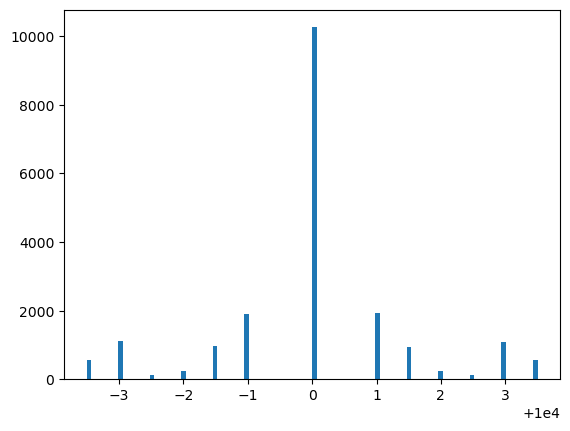

In [251]:
product = "RAINFOREST_RESIN"
plt.hist(book_df[book_df['product']==product]['mid_price'], bins=100)

(array([5149.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0., 9896.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0., 2875.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,  453.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1627.]),
 array([ 9995.  ,  9995.07,  9995.14,  9995.21,  9995.28,  9995.35,
         9995.42,  9995.49,  9995.56,  9995.63,  9995.7 ,  9995.77,
         9995.84,  9995.91,  9995.98,  9996.05,  9996.12,  9996.19

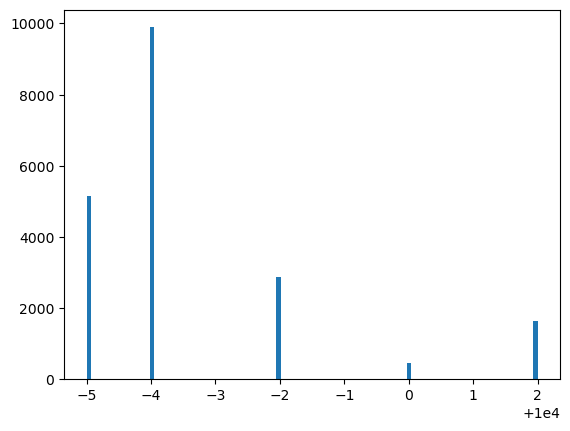

In [255]:
product = "RAINFOREST_RESIN"
plt.hist(book_df[book_df['product']==product]['bid_price_1'], bins=100)

In [205]:
trade_df[:30]

,timestamp,buyer,seller,symbol,currency,price,quantity
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5
5,6700,NaN,NaN,TOMATOES,XIRECS,4988.0,5
6,7100,NaN,NaN,TOMATOES,XIRECS,5000.0,3
7,10500,NaN,NaN,EMERALDS,XIRECS,10008.0,5
8,11200,NaN,NaN,TOMATOES,XIRECS,4985.0,4
9,11300,NaN,NaN,EMERALDS,XIRECS,9992.0,3


In [265]:
trade_df[10:15]

,timestamp,buyer,seller,symbol,currency,price,quantity
10,12700,NaN,NaN,TOMATOES,XIRECS,4999.0,2
11,13600,NaN,NaN,TOMATOES,XIRECS,4991.0,2
12,14100,NaN,NaN,TOMATOES,XIRECS,4998.0,2
13,17100,NaN,NaN,TOMATOES,XIRECS,4986.0,4
14,17800,NaN,NaN,TOMATOES,XIRECS,4986.0,5


In [267]:
book_df[book_df['product'] == 'TOMATOES'][134:143]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
269,-2,13400,TOMATOES,4986,8,4984,21,NaN,NaN,4999,8,5000,21,NaN,NaN,4992.5,0.0
271,-2,13500,TOMATOES,4985,5,4984,16,NaN,NaN,4999,5,5000,16,NaN,NaN,4992.0,0.0
273,-2,13600,TOMATOES,4991,3,4986,9,4984.0,25.0,4999,9,5000,25,NaN,NaN,4995.0,0.0
274,-2,13700,TOMATOES,4985,6,4984,22,NaN,NaN,4999,6,5000,22,NaN,NaN,4992.0,0.0
277,-2,13800,TOMATOES,4985,7,4984,24,NaN,NaN,4999,7,5000,24,NaN,NaN,4992.0,0.0
278,-2,13900,TOMATOES,4985,8,4984,15,NaN,NaN,4999,8,5000,15,NaN,NaN,4992.0,0.0
281,-2,14000,TOMATOES,4985,7,4984,16,NaN,NaN,4998,7,5000,16,NaN,NaN,4991.5,0.0
282,-2,14100,TOMATOES,4985,7,4984,22,NaN,NaN,4998,7,5000,22,NaN,NaN,4991.5,0.0
285,-2,14200,TOMATOES,4984,5,4983,18,NaN,NaN,4998,5,4999,18,NaN,NaN,4991.0,0.0


In [269]:
#14100로 확인가능

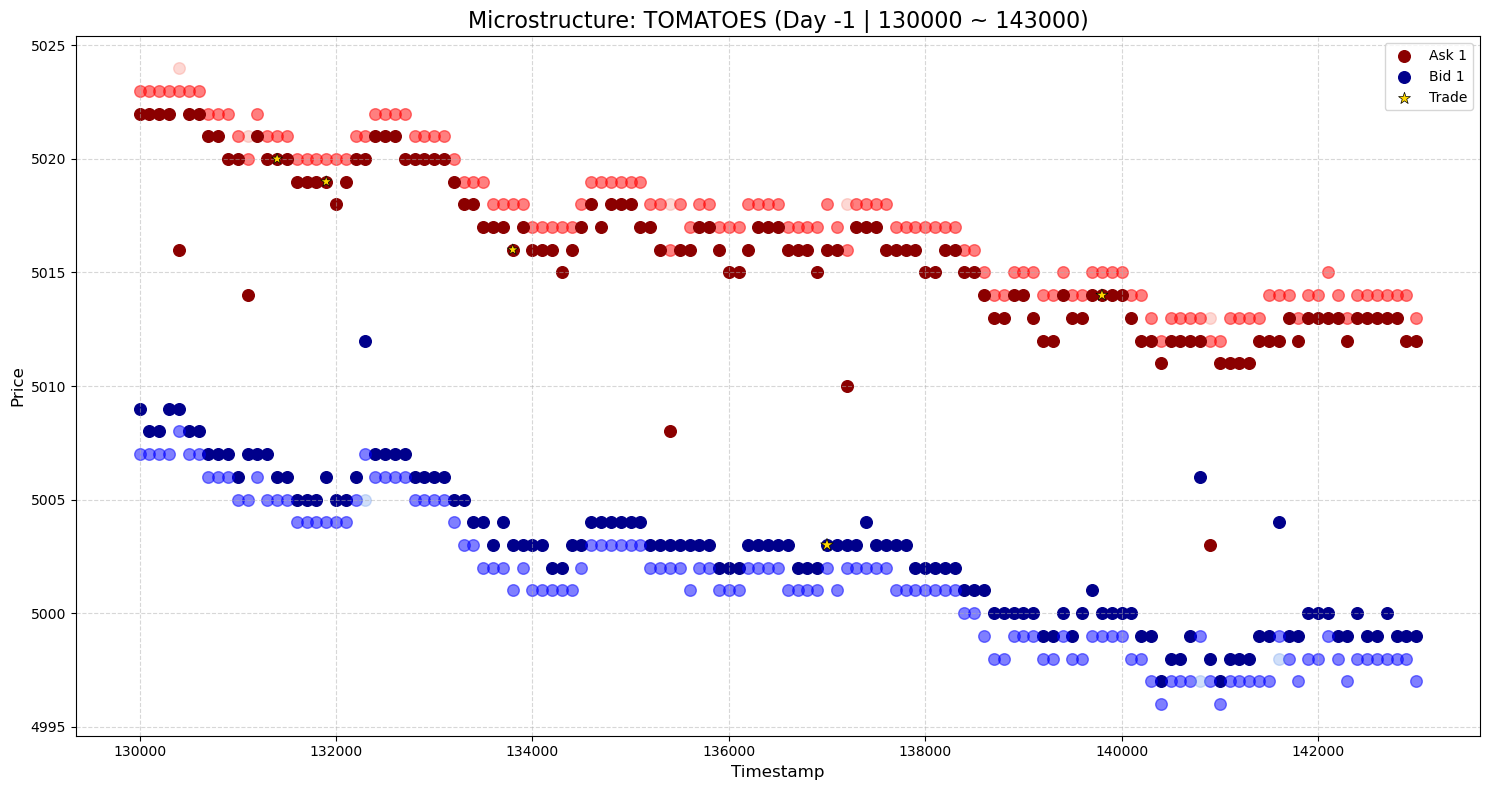

In [343]:
plot_order_book(book_df, trade_df, target_product='TOMATOES', target_day=-1, start_ts=130000, end_ts=143000)

In [273]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_spread_and_trade(book_df, trade_df, target_product, start_ts, end_ts, target_day=None):
    """
    위: 가격과 체결 (Price & Trade) - 점 그래프
    아래: 스프레드와 체결 시점 (Spread & Trade Timing) - 점 그래프
    """
    # 1. Book 데이터 필터링 및 Spread 계산
    book_cond = (book_df['product'] == target_product) & \
                (book_df['timestamp'] >= start_ts) & \
                (book_df['timestamp'] <= end_ts)

    book_filtered = book_df[book_cond].copy()
    book_filtered.sort_values('timestamp', inplace=True)
    
    # Spread (Ask 1 - Bid 1) 계산
    if not book_filtered.empty:
        book_filtered['spread'] = book_filtered['ask_price_1'] - book_filtered['bid_price_1']

    # 2. Trade 데이터 필터링
    symbol_col = 'symbol' if 'symbol' in trade_df.columns else 'product'
    trade_cond = (trade_df[symbol_col] == target_product) & \
                 (trade_df['timestamp'] >= start_ts) & \
                 (trade_df['timestamp'] <= end_ts)
        
    trade_filtered = trade_df[trade_cond].copy()

    if book_filtered.empty:
        print("해당 구간에 오더북 데이터가 없습니다.")
        return

    # 3. 그래프 그리기 (위/아래 2개 패널)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    # 점의 기본 크기 설정
    dot_size = 80

    # --- [상단 패널] 오더북 Price & Trade ---
    # 선(step)을 점(scatter)으로 변경
    ax1.scatter(book_filtered['timestamp'], book_filtered['ask_price_1'], color='darkred', label='Ask 1', s=dot_size)
    ax1.scatter(book_filtered['timestamp'], book_filtered['bid_price_1'], color='darkblue', label='Bid 1', s=dot_size)
    
    if not trade_filtered.empty:
        # 거래량에 비례하여 마커 크기 설정 (별표 크기도 비율에 맞게 조정)
        sizes = 150 + (trade_filtered['quantity'] * 20) if 'quantity' in trade_filtered.columns else 200
        ax1.scatter(trade_filtered['timestamp'], trade_filtered['price'],
                   color='gold', marker='*', s=sizes, label='Trade', zorder=5, edgecolor='black', linewidth=0.5)
    
    day_str = f"Day {target_day} | " if target_day is not None else ""
    ax1.set_title(f"Spread & Trade Analysis: {target_product} ({day_str}{start_ts} ~ {end_ts})", fontsize=16)
    ax1.set_ylabel("Price", fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # --- [하단 패널] Spread & Trade Timing ---
    # 선(step)을 점(scatter)으로 변경
    ax2.scatter(book_filtered['timestamp'], book_filtered['spread'], color='purple', label='Spread (Ask1 - Bid1)', s=dot_size)
    
    # 체결(Trade)이 발생한 시점을 수직선으로 표시하여 스프레드와의 관계 확인
    if not trade_filtered.empty:
        for _, row in trade_filtered.iterrows():
            # 거래량에 따라 수직선의 진하기(alpha) 조절 (큰 거래일수록 진하게)
            alpha_val = min(0.8, 0.3 + (row['quantity'] * 0.05)) if 'quantity' in trade_filtered.columns else 0.5
            ax2.axvline(x=row['timestamp'], color='orange', linestyle='--', alpha=alpha_val, zorder=1)
        
        # 범례 표시를 위한 빈 플롯
        ax2.plot([], [], color='orange', linestyle='--', label='Trade Event')

    ax2.set_xlabel("Timestamp", fontsize=12)
    ax2.set_ylabel("Spread", fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.ticklabel_format(style='plain', axis='x') # 지수 표현 방지

    plt.tight_layout()
    plt.show()

# 실행 예시:
# plot_spread_and_trade(book_df, trade_df, target_product='TOMATOES', start_ts=13000, end_ts=14300, target_day=-1)

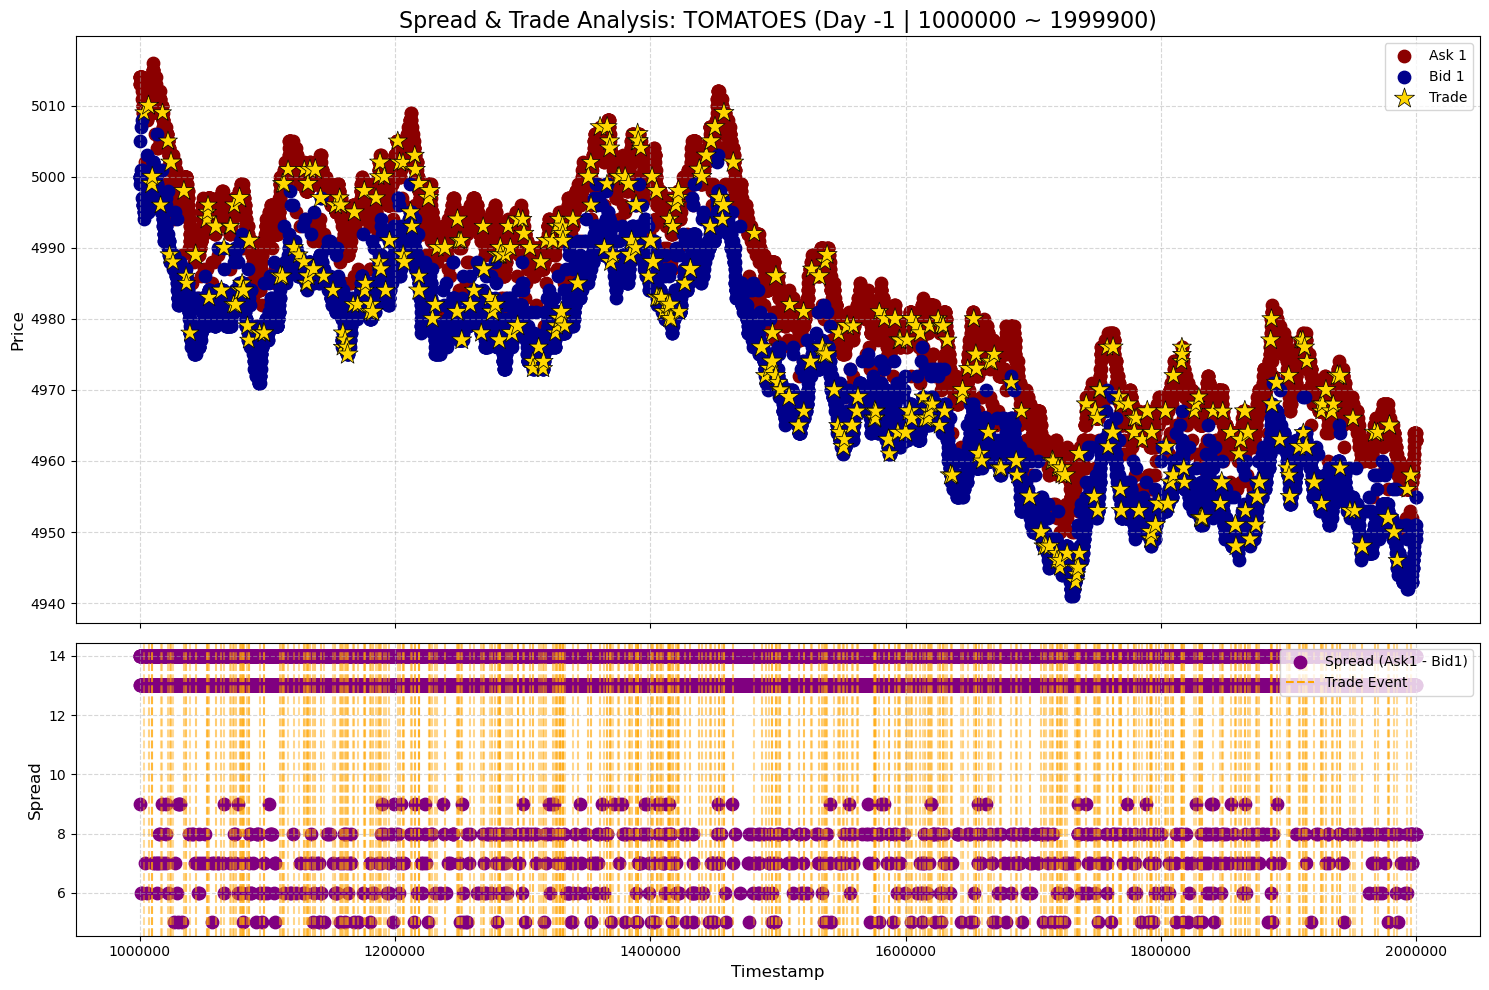

In [347]:
plot_spread_and_trade(book_df, trade_df, target_product='TOMATOES', start_ts=1000000, end_ts=1999900, target_day=-1)

In [279]:
book_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,-1,1999700,EMERALDS,9992,12,9990,26,NaN,NaN,10008,12,10010,26,NaN,NaN,10000.0,0.0
39996,-1,1999800,EMERALDS,9992,13,9990,20,NaN,NaN,10008,13,10010,20,NaN,NaN,10000.0,0.0
39997,-1,1999800,TOMATOES,4951,6,4949,18,NaN,NaN,4964,6,4965,18,NaN,NaN,4957.5,0.0
39998,-1,1999900,TOMATOES,4950,10,4949,25,NaN,NaN,4964,10,4965,25,NaN,NaN,4957.0,0.0


(array([209.,   0.,   0., 270.,   0.,   0., 265.,   0.,   0.,   0., 271.,
          0.,   0.,  87.,   0.,   0.,  59.,   0.,   0.,  58.]),
 array([2. , 2.3, 2.6, 2.9, 3.2, 3.5, 3.8, 4.1, 4.4, 4.7, 5. , 5.3, 5.6,
        5.9, 6.2, 6.5, 6.8, 7.1, 7.4, 7.7, 8. ]),
 <BarContainer object of 20 artists>)

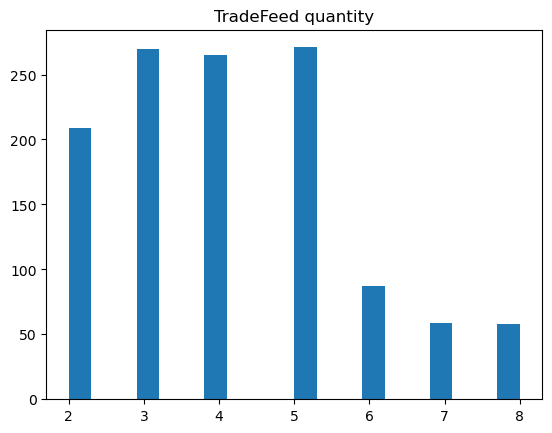

In [303]:
plt.title("TradeFeed quantity")
plt.hist(trade_df['quantity'], bins=20)

In [307]:
trade_df

,timestamp,buyer,seller,symbol,currency,price,quantity
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5
...,...,...,...,...,...,...,...
1214,1983800,NaN,NaN,EMERALDS,XIRECS,10008.0,3
1215,1985100,NaN,NaN,TOMATOES,XIRECS,4946.0,2
1216,1985600,NaN,NaN,EMERALDS,XIRECS,10008.0,6
1217,1993000,NaN,NaN,TOMATOES,XIRECS,4956.0,2


In [339]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_post_trade_impact(trade_df, book_df, target_product='TOMATOES', target_qty=8, interval=500):
    # 1. order book 세팅
    book = book_df[book_df['product'] == target_product].copy()
    book['mid_price'] = (book['bid_price_1'] + book['ask_price_1']) / 2
    book_idx = book.set_index('timestamp')

    # 2. 타겟 거래 필터링
    trades = trade_df[(trade_df['symbol'] == target_product) & (trade_df['quantity'] == target_qty)].copy()

    results = []

    # 3. 각 거래별로 N 틱(interval) 이후의 가격 변화 추적
    for _, trade in trades.iterrows():
        t = trade['timestamp']
        trade_price = trade['price']

        future_t = t + interval
        if t not in book_idx.index or future_t not in book_idx.index:
            continue

        current_mid = book_idx.loc[t, 'mid_price']
        ask_1 = book_idx.loc[t, 'ask_price_1']
        bid_1 = book_idx.loc[t, 'bid_price_1']

        # 거래 방향 (Buy/Sell) 추론 - 영어로 변경
        if trade_price >= ask_1:
            direction = 'Buy'
        elif trade_price <= bid_1:
            direction = 'Sell'
        else:
            direction = 'Unknown'

        if direction == 'Unknown':
            continue

        price_change = book_idx.loc[future_t, 'mid_price'] - current_mid

        results.append({
            'timestamp': t,
            'direction': direction,
            'price_change': price_change
        })

    res_df = pd.DataFrame(results)

    if res_df.empty:
        print(f"No data found for quantity {target_qty}.")
        return

    # --- 시각화 ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 한글 라벨 제거 및 영어 지정
    sns.barplot(data=res_df, x='direction', y='price_change', ax=axes[0],
                palette={'Buy': 'red', 'Sell': 'blue'}, errorbar=('ci', 95))
    axes[0].set_title(f'Avg Price Change after {interval} ticks (Qty={target_qty})')
    axes[0].set_ylabel('Mid Price Change (Future - Current)')
    axes[0].axhline(0, color='black', linestyle='--')

    sns.boxplot(data=res_df, x='direction', y='price_change', ax=axes[1],
                palette={'Buy': 'red', 'Sell': 'blue'})
    axes[1].set_title(f'Distribution of Price Change (Qty={target_qty})')
    axes[1].set_ylabel('Mid Price Change')
    axes[1].axhline(0, color='black', linestyle='--')

    plt.suptitle(f'{target_product} - Post Trade Impact Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()

    # 터미널 출력 텍스트 영어로 변경
    avg_impact = res_df.groupby('direction')['price_change'].mean().round(2)
    print(f"\n[{target_product} | Qty={target_qty} | Interval={interval}] Average Price Change:")
    print(avg_impact)

/var/folders/qz/5dkq_4wj0yq8v0bd99hhn7g00000gn/T/ipykernel_30214/1477381572.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x='direction', y='price_change', ax=axes[0],
/var/folders/qz/5dkq_4wj0yq8v0bd99hhn7g00000gn/T/ipykernel_30214/1477381572.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=res_df, x='direction', y='price_change', ax=axes[1],


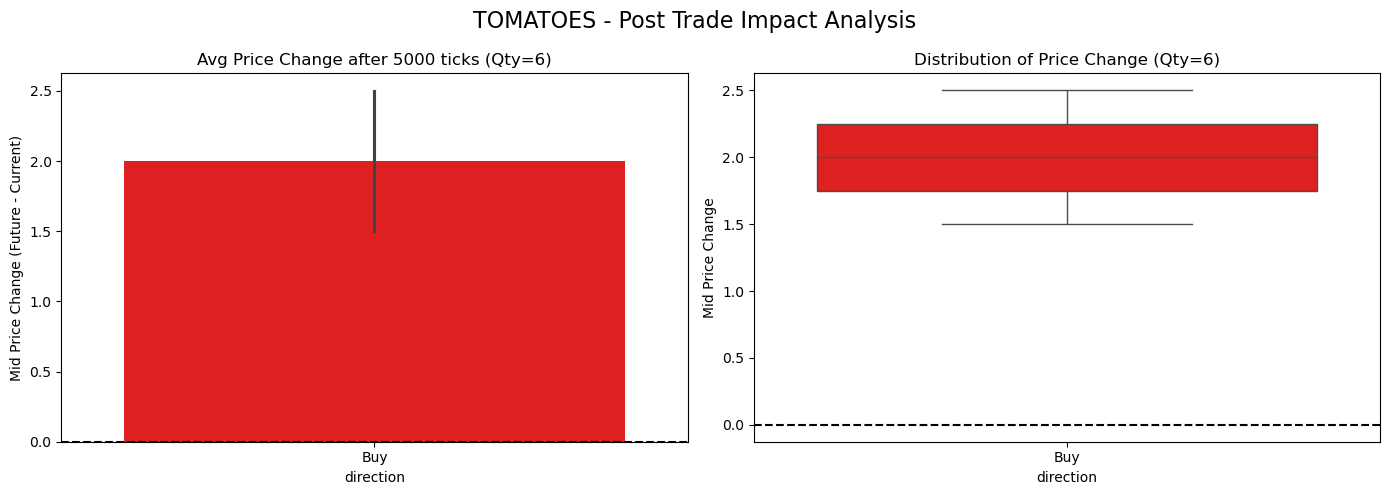


[TOMATOES | Qty=6 | Interval=5000] Average Price Change:
direction
Buy    2.0
Name: price_change, dtype: float64


In [351]:
analyze_post_trade_impact(trade_df, book_df, target_product='TOMATOES', target_qty=6, interval=5000)

In [337]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_book_pressure(book_df, target_product, start_ts, end_ts, target_day=None, window=30):
    """
    위: Mid Price (가격 흐름)
    아래: Smoothed Book Pressure (매수/매도 압력)
    window 파라미터로 이동평균 윈도우 크기를 조절하여 노이즈를 필터링합니다.
    """
    # 1. Book 데이터 필터링
    book_cond = (book_df['product'] == target_product) & \
                (book_df['timestamp'] >= start_ts) & \
                (book_df['timestamp'] <= end_ts)
    
    if target_day is not None and 'day' in book_df.columns:
        book_cond &= (book_df['day'] == target_day)
        
    df = book_df[book_cond].copy()
    df.sort_values('timestamp', inplace=True)

    if df.empty:
        print("해당 구간에 오더북 데이터가 없습니다.")
        return

    # 2. 지표 계산
    # Mid Price 계산 (Ask 1과 Bid 1의 중간값)
    df['mid_price'] = (df['ask_price_1'] + df['bid_price_1']) / 2
    
    # Raw OBI (Book Pressure) 계산: [-1, 1]
    df['obi'] = (df['bid_volume_1'] - df['ask_volume_1']) / (df['bid_volume_1'] + df['ask_volume_1'])
    
    # Smoothed OBI 계산 (단순 이동평균을 사용하여 노이즈 제거)
    df['obi_smoothed'] = df['obi'].rolling(window=window, min_periods=1).mean()

    # 3. 그래프 그리기
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    # --- [상단 패널] Mid Price ---
    ax1.plot(df['timestamp'], df['mid_price'], color='black', linewidth=1.5, label='Mid Price')
    
    day_str = f"Day {target_day} | " if target_day is not None else ""
    ax1.set_title(f"Price & Book Pressure Analysis: {target_product} ({day_str}Rolling Window: {window})", fontsize=16)
    ax1.set_ylabel("Mid Price", fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # --- [하단 패널] Smoothed Book Pressure ---
    # 중심선(0) 긋기
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
    
    # OBI 선 그리기
    ax2.plot(df['timestamp'], df['obi_smoothed'], color='purple', linewidth=1.5, label=f'Smoothed OBI (Window={window})')
    
    # 시각적 직관성을 위해 0보다 크면 파란색(매수 압력), 0보다 작으면 빨간색(매도 압력)으로 칠하기
    ax2.fill_between(df['timestamp'], 0, df['obi_smoothed'], where=(df['obi_smoothed'] >= 0), color='blue', alpha=0.3, interpolate=True)
    ax2.fill_between(df['timestamp'], 0, df['obi_smoothed'], where=(df['obi_smoothed'] < 0), color='red', alpha=0.3, interpolate=True)

    ax2.set_xlabel("Timestamp", fontsize=12)
    ax2.set_ylabel("Book Pressure (OBI)", fontsize=12)
    ax2.set_ylim(-0.3, 0.3) # OBI는 항상 -1과 1 사이
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.ticklabel_format(style='plain', axis='x')

    plt.tight_layout()
    plt.show()

# 실행 예시: (전체 구간을 보려면 아래처럼 실행)
# plot_book_pressure(book_df, target_product='TOMATOES', start_ts=10000, end_ts=1999900, target_day=-1, window=500)

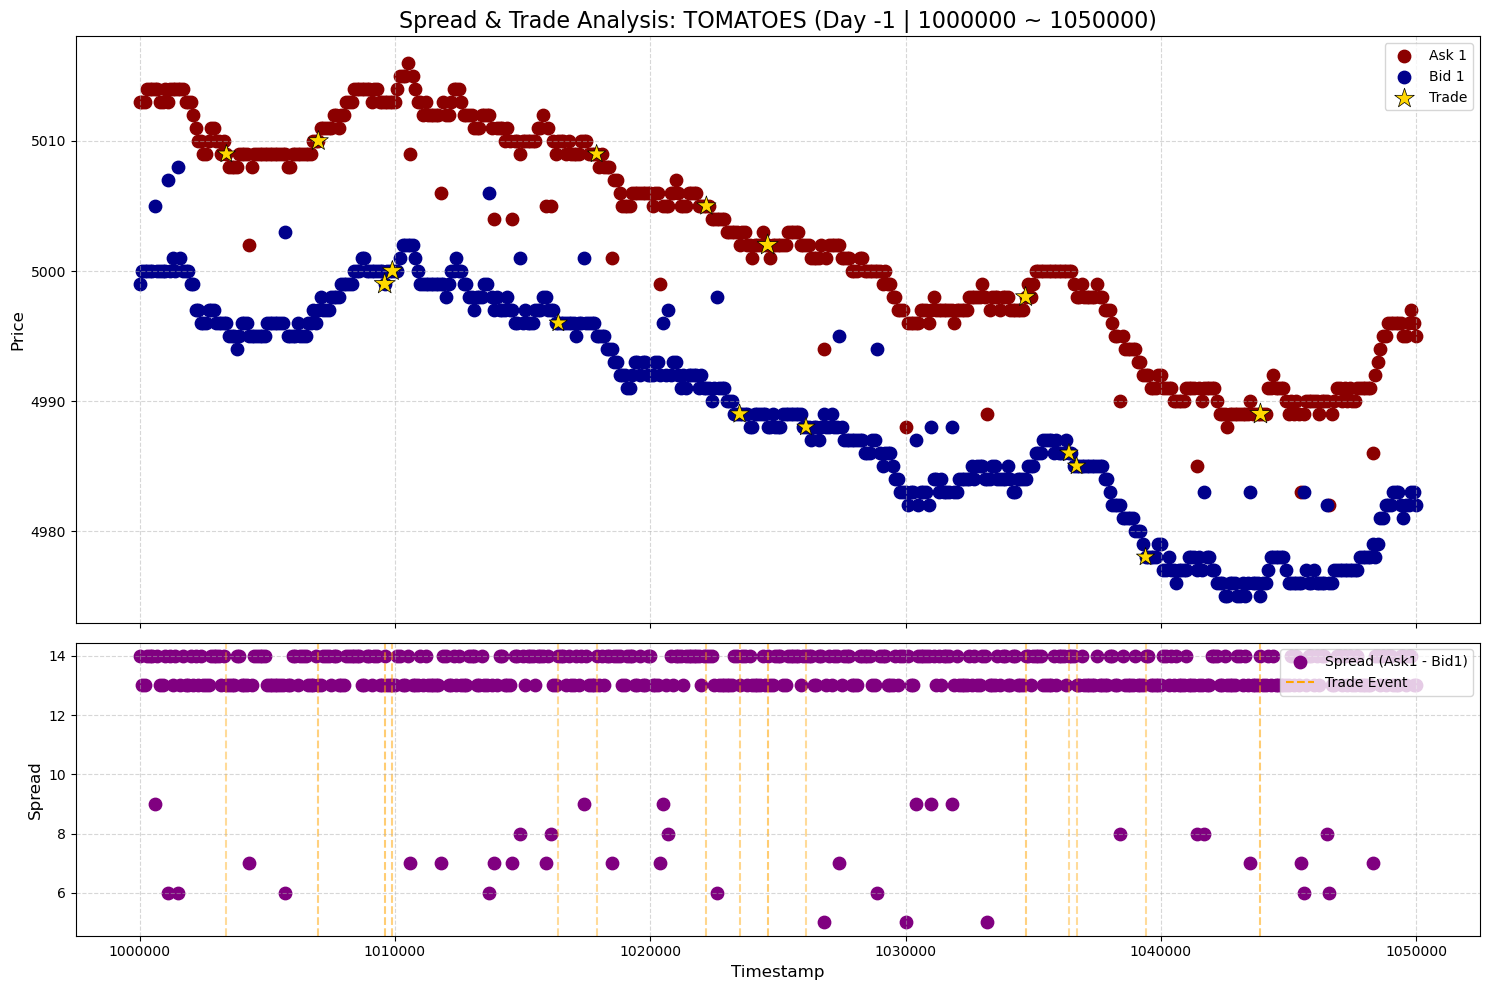

In [295]:
plot_spread_and_trade(book_df, trade_df, target_product='TOMATOES', start_ts=1000000, end_ts=1050000, target_day=-1)

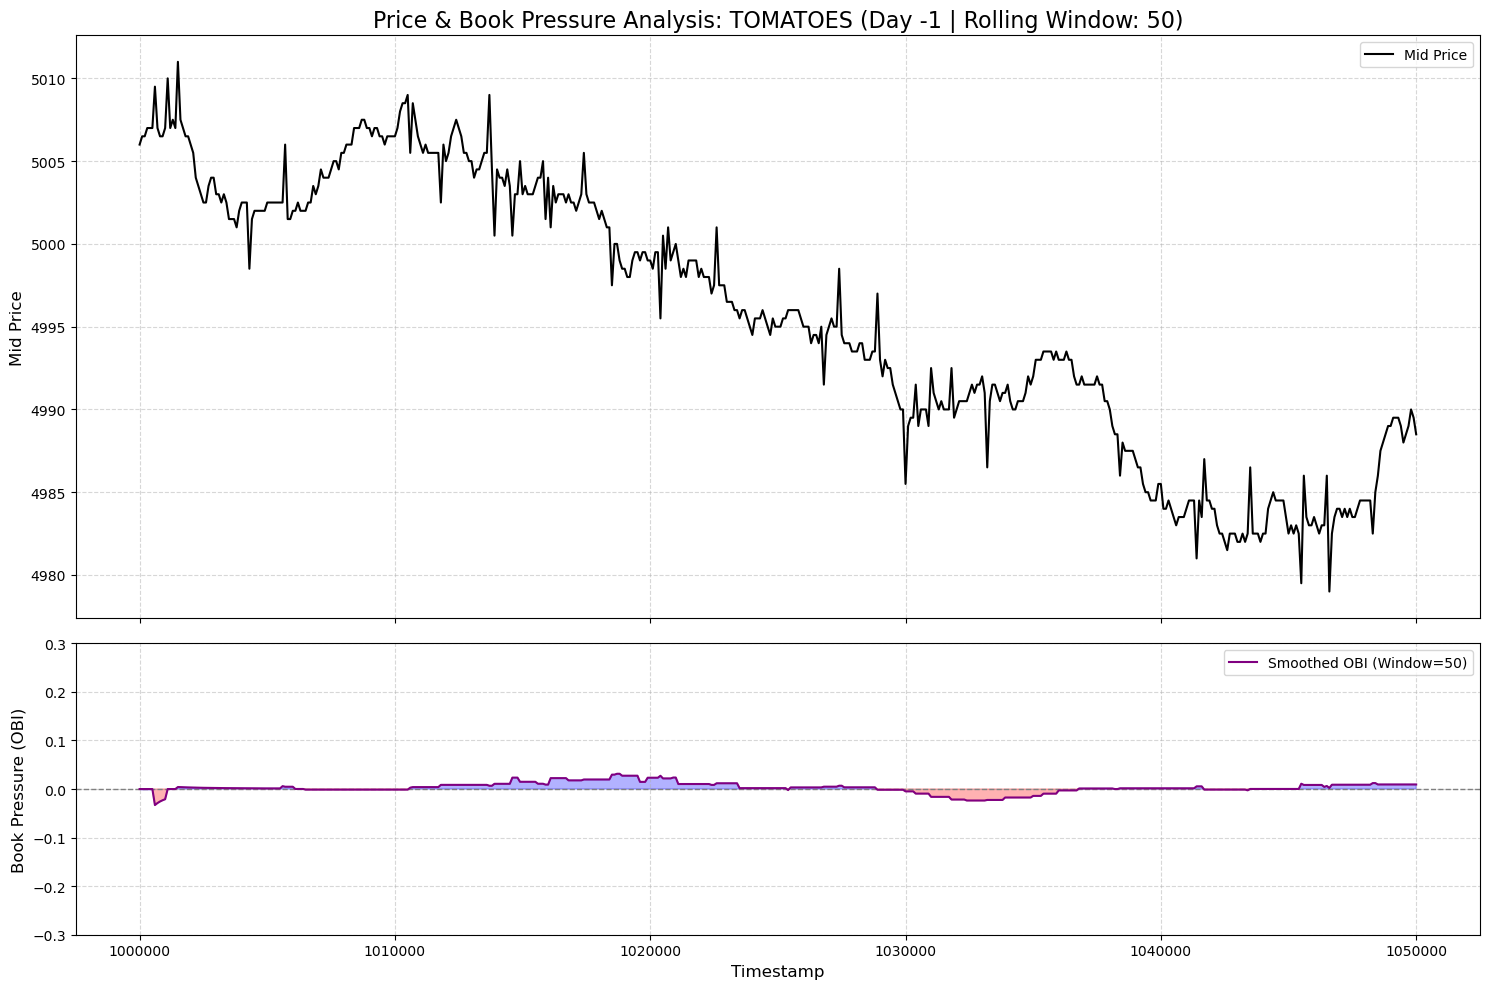

In [355]:
plot_book_pressure(book_df, target_product='TOMATOES', start_ts=1000000, end_ts=1050000, target_day=-1, window=50)

In [ ]:
level 1 

[TOMATOES] Book Pressure와 Future Price Change의 상관계수: 0.3258


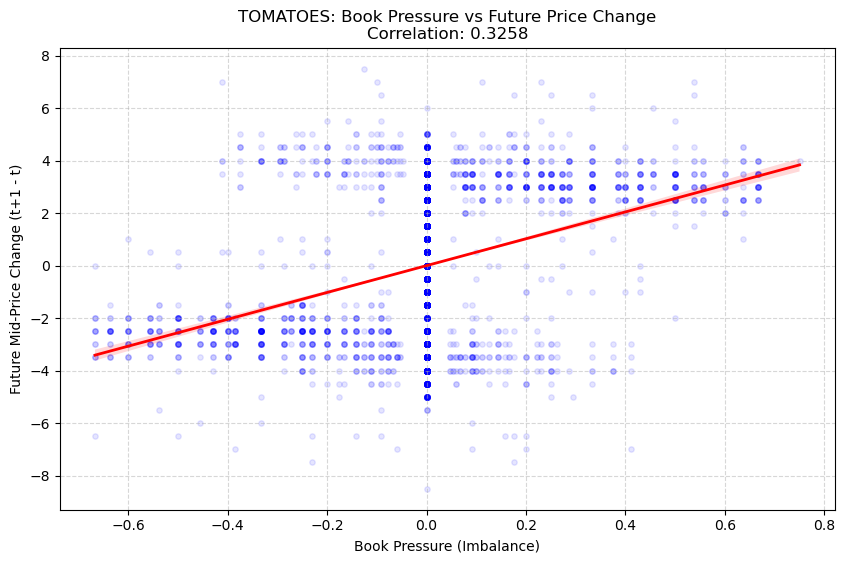

In [291]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pressure_vs_price_change(df: pd.DataFrame, target_product: str):
    # 1. 특정 상품 필터링 및 시간순 정렬
    prod_df = df[df['product'] == target_product].copy()
    prod_df = prod_df.sort_values(by=['day', 'timestamp']).reset_index(drop=True)

    # 2. Mid Price 계산: (최우선 매수호가 + 최우선 매도호가) / 2
    prod_df['mid_price'] = (prod_df['bid_price_1'] + prod_df['ask_price_1']) / 2

    # 3. Book Pressure (Order Book Imbalance) 계산
    # 레벨 1 호가 기준: (매수잔량 - 매도잔량) / (매수잔량 + 매도잔량)
    # 1에 가까울수록 매수세가 강함, -1에 가까울수록 매도세가 강함
    prod_df['book_pressure'] = (prod_df['bid_volume_1'] - prod_df['ask_volume_1']) / \
                               (prod_df['bid_volume_1'] + prod_df['ask_volume_1'])

    # 4. 미래 가격 변화량 (Future Price Change) 계산
    # 다음 틱(t+1)의 Mid Price에서 현재 틱(t)의 Mid Price를 뺌
    prod_df['future_price_change'] = prod_df['mid_price'].shift(-1) - prod_df['mid_price']

    # 결측치 제거 (shift로 인해 마지막 행에 NaN이 발생함)
    prod_df = prod_df.dropna(subset=['book_pressure', 'future_price_change'])

    # 5. 상관계수(Correlation) 계산
    correlation = prod_df['book_pressure'].corr(prod_df['future_price_change'])
    print(f"[{target_product}] Book Pressure와 Future Price Change의 상관계수: {correlation:.4f}")

    # 6. Scatter Plot (산점도) 시각화
    plt.figure(figsize=(10, 6))
    
    # seaborn의 regplot을 사용하면 산점도 위에 선형 회귀선(트렌드 라인)을 그어주어 직관적입니다.
    sns.regplot(
        data=prod_df, 
        x='book_pressure', 
        y='future_price_change', 
        scatter_kws={'alpha': 0.1, 's': 15, 'color': 'blue'}, # 데이터가 많으므로 투명도(alpha) 조절
        line_kws={'color': 'red', 'linewidth': 2}
    )
    
    plt.title(f"{target_product}: Book Pressure vs Future Price Change\nCorrelation: {correlation:.4f}")
    plt.xlabel("Book Pressure (Imbalance)")
    plt.ylabel("Future Mid-Price Change (t+1 - t)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 사용 예시 (앞서 로드한 book_df를 넣고 실행하시면 됩니다)
plot_pressure_vs_price_change(book_df, target_product='TOMATOES')